In [1]:
import great_expectations as gx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.experimental import enable_iterative_imputer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import IterativeImputer
imp = IterativeImputer(random_state=0, max_iter=50)
scaler = StandardScaler()

In [2]:
context = gx.get_context()
datasource = context.data_sources.add_pandas(name="pandas_ds")
data_asset = datasource.add_dataframe_asset(name="uci_asset")
df_uci = pd.read_parquet('../data/processed/uci_air_quality_cleaned.parquet')
df_global = pd.read_parquet('../data/processed/global_air_quality.parquet')
df_hanoi = pd.read_parquet('../data/processed/hanoi_air_quality_cleaned.parquet')
df_vietnam = pd.read_parquet('../data/processed/vietnam_air_quality_cleaned.parquet')

In [3]:
df_uci

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
DateTime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.00,150.0,11.881723,1045.50,166.000000,1056.25,113.000000,1692.00,1267.50,13.600000,48.875000,0.757754
2004-03-10 19:00:00,2.0,1292.25,112.0,9.397165,954.75,103.000000,1173.75,92.000000,1558.75,972.25,13.300000,47.700001,0.725487
2004-03-10 20:00:00,2.2,1402.00,88.0,8.997817,939.25,131.000000,1140.00,114.000000,1554.50,1074.00,11.900000,53.975002,0.750239
2004-03-10 21:00:00,2.2,1375.50,80.0,9.228796,948.25,172.000000,1092.00,122.000000,1583.75,1203.25,11.000000,60.000000,0.786713
2004-03-10 22:00:00,1.6,1272.25,51.0,6.518224,835.50,131.000000,1205.00,116.000000,1490.00,1110.00,11.150000,59.575001,0.788794
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2005-04-04 10:00:00,3.1,1314.25,NaN,13.529605,1101.25,471.700012,538.50,189.800003,1374.25,1728.50,21.850000,29.250000,0.756824
2005-04-04 11:00:00,2.4,1162.50,NaN,11.355158,1027.00,353.299988,603.75,179.199997,1263.50,1269.00,24.325001,23.725000,0.711864
2005-04-04 12:00:00,2.4,1142.00,NaN,12.374538,1062.50,293.000000,603.25,174.699997,1240.75,1092.00,26.900000,18.350000,0.640649


In [4]:
df_uci.corr()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
CO(GT),1.000000,0.879292,0.889734,0.931091,0.915519,0.795054,-0.703433,0.683533,0.630700,0.854183,0.022113,0.048896,0.048555
PT08.S1(CO),0.879292,1.000000,0.790677,0.883821,0.892972,0.713687,-0.771918,0.641696,0.682874,0.899326,0.048628,0.114607,0.135323
NMHC(GT),0.889734,0.790677,1.000000,0.902599,0.877691,0.812685,-0.771111,0.731193,0.853278,0.766731,0.391730,-0.191486,0.269734
C6H6(GT),0.931091,0.883821,0.902599,1.000000,0.981962,0.718914,-0.735711,0.614753,0.765717,0.865727,0.198891,-0.061643,0.167909
PT08.S2(NMHC),0.915519,0.892972,0.877691,0.981962,1.000000,0.704483,-0.796687,0.646520,0.777235,0.880590,0.241330,-0.090352,0.186906
NOx(GT),0.795054,0.713687,0.812685,0.718914,0.704483,1.000000,-0.655690,0.763170,0.233777,0.787056,-0.269713,0.221022,-0.149279
PT08.S3(NOx),-0.703433,-0.771918,-0.771111,-0.735711,-0.796687,-0.655690,1.000000,-0.652138,-0.538460,-0.796554,-0.145133,-0.056730,-0.232021
NO2(GT),0.683533,0.641696,0.731193,0.614753,0.646520,0.763170,-0.652138,1.000000,0.157678,0.708259,-0.186369,-0.091845,-0.334798
PT08.S4(NO2),0.630700,0.682874,0.853278,0.765717,0.777235,0.233777,-0.538460,0.157678,1.000000,0.591137,0.561333,-0.032188,0.629644
PT08.S5(O3),0.854183,0.899326,0.766731,0.865727,0.880590,0.787056,-0.796554,0.708259,0.591137,1.000000,-0.027193,0.124952,0.070738


In [5]:
df_hanoi.set_index('date', inplace=True)
df_hanoi.index = pd.to_datetime(df_hanoi.index.astype(str))
df_hanoi.index.dtype

dtype('<M8[ns]')

In [6]:
df_hanoi = df_hanoi.sort_index()
time_hanoi_diff = df_hanoi.index.to_series().diff()
time_hanoi_diff.describe()

count                         3487
mean     1 days 06:45:06.968741038
std      7 days 22:48:29.771771776
min                1 days 00:00:00
25%                1 days 00:00:00
50%                1 days 00:00:00
75%                1 days 00:00:00
max              373 days 00:00:00
Name: date, dtype: object

In [7]:
time_diff = df_uci.index.to_series().diff()
time_diff.describe()

count               9356
mean     0 days 01:00:00
std      0 days 00:00:00
min      0 days 01:00:00
25%      0 days 01:00:00
50%      0 days 01:00:00
75%      0 days 01:00:00
max      0 days 01:00:00
Name: DateTime, dtype: object

<Axes: ylabel='DateTime'>

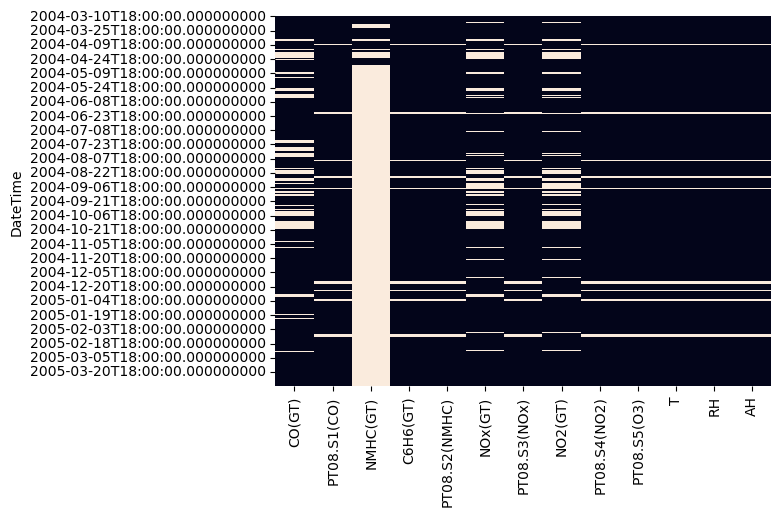

In [8]:
plt.ylabel('Date Time')
sns.heatmap(df_uci.isna(), cbar=False)

In [9]:
df_uci_copy = df_uci.copy()
df_uci_copy.drop(columns=['NMHC(GT)'], inplace=True)

In [10]:
valid = df_uci_copy['CO(GT)'].dropna()
gap = valid.index.to_series().diff()
gap.sort_values(ascending=False)

DateTime
2004-10-20 16:00:00   7 days 06:00:00
2004-04-23 05:00:00   6 days 03:00:00
2004-10-07 16:00:00   5 days 23:00:00
2004-07-31 05:00:00   5 days 03:00:00
2005-01-01 01:00:00   4 days 01:00:00
                            ...      
2004-07-16 18:00:00   0 days 01:00:00
2004-07-16 17:00:00   0 days 01:00:00
2004-07-16 16:00:00   0 days 01:00:00
2005-04-04 14:00:00   0 days 01:00:00
2004-03-10 18:00:00               NaT
Name: DateTime, Length: 7674, dtype: timedelta64[ns]

In [11]:
valid.index

DatetimeIndex(['2004-03-10 18:00:00', '2004-03-10 19:00:00',
               '2004-03-10 20:00:00', '2004-03-10 21:00:00',
               '2004-03-10 22:00:00', '2004-03-10 23:00:00',
               '2004-03-11 00:00:00', '2004-03-11 01:00:00',
               '2004-03-11 02:00:00', '2004-03-11 03:00:00',
               ...
               '2005-04-04 05:00:00', '2005-04-04 06:00:00',
               '2005-04-04 07:00:00', '2005-04-04 08:00:00',
               '2005-04-04 09:00:00', '2005-04-04 10:00:00',
               '2005-04-04 11:00:00', '2005-04-04 12:00:00',
               '2005-04-04 13:00:00', '2005-04-04 14:00:00'],
              dtype='datetime64[ns]', name='DateTime', length=7674, freq=None)

In [12]:
df_vietnam.columns

Index(['Station ID', 'AQI index', 'Location', 'Station name', 'Url',
       'Dominent pollutant', 'CO', 'Dew', 'Humidity', 'NO2', 'O3', 'Pressure',
       'PM10', 'PM2.5', 'SO2', 'Temperature', 'Wind', 'Data Time Tz', 'Status',
       'Alert level'],
      dtype='object')

# Xử lý số âm

In [13]:
df_global_copy = df_global.copy()

In [14]:
def handle_negative_value(df, cols):
    df_clean = df.copy()
    for col in cols:
        df_clean.loc[df_clean[col]<=0,col] = np.nan

        df_clean[col] = df_clean[col].interpolate(method='linear')
    return df_clean
df_uci_col = ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)']
df_uci_capped = handle_negative_value(df_uci_copy, df_uci_col)
df_global_col = ['CO', 'NO2', 'SO2', 'O3', 'PM2.5', 'PM10', 'AQI']
df_global_capped = handle_negative_value(df_global_copy, df_global_col)
df_vietnam_col = df_vietnam.select_dtypes(include=['number']).columns
df_vietnam_capped = handle_negative_value(df_vietnam, df_vietnam_col)


## Xử lý missing data

In [15]:
#Hàm để fill na value
def impute_value(df, cols):

    for col in cols:
        df[f"{col}_raw"] = df[col]
        df[f"{col}_imputed"] = df[col].isna()

    df[cols] = (
        df[cols]
        .interpolate(method="time", limit=2)
        .ffill(limit=4)
    )
    scaled = scaler.fit_transform(df[cols])
    imputer = imp.fit_transform(scaled)
    df[cols] = scaler.inverse_transform(imputer)

    return df

In [16]:
df_uci_copy.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9357 entries, 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         7674 non-null   float32
 1   PT08.S1(CO)    8991 non-null   float32
 2   C6H6(GT)       8991 non-null   float32
 3   PT08.S2(NMHC)  8991 non-null   float32
 4   NOx(GT)        7718 non-null   float32
 5   PT08.S3(NOx)   8991 non-null   float32
 6   NO2(GT)        7715 non-null   float32
 7   PT08.S4(NO2)   8991 non-null   float32
 8   PT08.S5(O3)    8991 non-null   float32
 9   T              8991 non-null   float32
 10  RH             8991 non-null   float32
 11  AH             8991 non-null   float32
dtypes: float32(12)
memory usage: 511.7 KB


In [17]:
cols = ['CO(GT)','PT08.S1(CO)','C6H6(GT)','PT08.S2(NMHC)','NOx(GT)','PT08.S3(NOx)',	'NO2(GT)','PT08.S4(NO2)',	'PT08.S5(O3)','T','RH','AH']
df_uci_copy = impute_value(df_uci_copy,cols)

D:\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [18]:
df_vietnam_capped.index

Index(['1/21/2021 19:00', '1/21/2021 19:00', '1/21/2021 19:00',
       '1/21/2021 19:00', '1/21/2021 19:00', '1/21/2021 19:00',
       '1/21/2021 19:00', '1/21/2021 19:00', '1/21/2021 19:00',
       '1/21/2021 19:00',
       ...
       '9/8/2021 8:00', '9/8/2021 9:00', '9/8/2021 9:00', '9/8/2021 9:00',
       '9/8/2021 9:00', '9/8/2021 9:00', '9/8/2021 9:00', '9/8/2021 9:00',
       '9/8/2021 9:00', '9/9/2021 2:00'],
      dtype='object', name='DateTime', length=2621)

In [19]:
df_vietnam_capped.index = pd.to_datetime(df_vietnam_capped.index)

In [20]:
df_vietnam_capped.index.dtype

dtype('<M8[ns]')

In [21]:
df_vietnam_capped = impute_value(df_vietnam_capped,df_vietnam_col)

In [22]:
df_hanoi.columns

Index(['pm25', 'pm10', 'o3', 'no2', 'so2', 'co'], dtype='object')

In [23]:
cols_hanoi = ['pm25', 'pm10', 'o3', 'no2', 'so2', 'co']
df_hanoi = impute_value(df_hanoi, cols_hanoi)

In [24]:
df_hanoi.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3488 entries, 2014-01-01 to 2026-03-27
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   pm25          3488 non-null   float64
 1   pm10          3488 non-null   float64
 2   o3            3488 non-null   float64
 3   no2           3488 non-null   float64
 4   so2           3488 non-null   float64
 5   co            3488 non-null   float64
 6   pm25_raw      3212 non-null   float64
 7   pm25_imputed  3488 non-null   bool   
 8   pm10_raw      3213 non-null   float64
 9   pm10_imputed  3488 non-null   bool   
 10  o3_raw        2818 non-null   float64
 11  o3_imputed    3488 non-null   bool   
 12  no2_raw       2906 non-null   float64
 13  no2_imputed   3488 non-null   bool   
 14  so2_raw       2913 non-null   float64
 15  so2_imputed   3488 non-null   bool   
 16  co_raw        2839 non-null   float64
 17  co_imputed    3488 non-null   bool   
dtypes: bool(6)

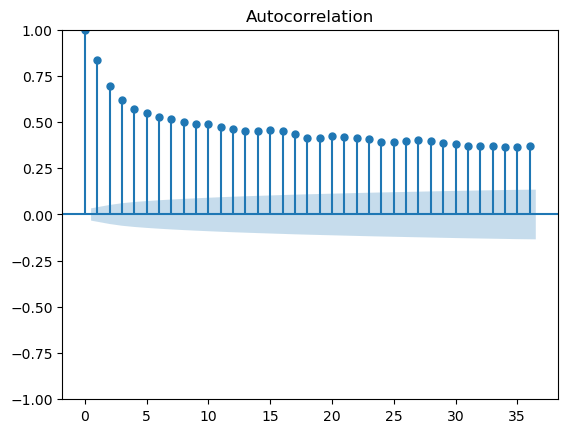

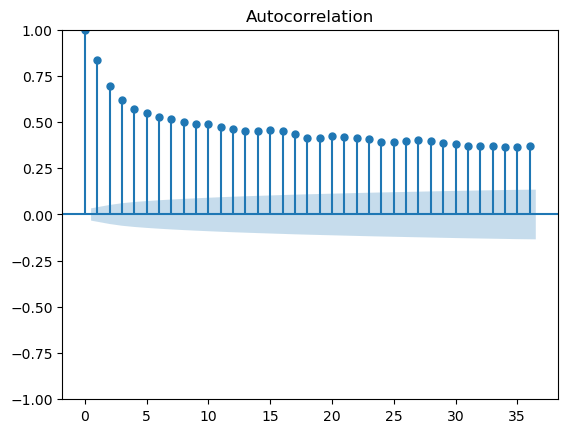

In [25]:
plot_acf(df_hanoi['pm25'])

In [26]:
df_uci_copy.describe()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,...,C6H6(GT)_raw,PT08.S2(NMHC)_raw,NOx(GT)_raw,PT08.S3(NOx)_raw,NO2(GT)_raw,PT08.S4(NO2)_raw,PT08.S5(O3)_raw,T_raw,RH_raw,AH_raw
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,...,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000
mean,2.097562,1102.555786,10.190272,942.769714,236.537354,832.140991,109.295296,1455.751465,1029.379272,18.264782,...,10.082993,939.029236,246.881256,835.370911,113.075516,1456.143433,1022.780640,18.316055,49.232361,1.025530
std,1.443965,217.663467,7.493811,267.877686,207.589172,256.335571,47.309483,342.293579,402.552734,8.752636,...,7.449648,266.828857,212.971237,256.814911,48.359291,346.204742,398.480621,8.832889,17.316393,0.403813
min,0.044674,647.250000,0.149048,383.250000,-78.758553,-22.363789,-6.393669,551.000000,220.999954,-1.900000,...,0.149048,383.250000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.175000,0.184679
25%,1.000000,939.250000,4.519882,738.750000,91.999992,656.750000,74.000000,1235.000000,736.750000,11.875000,...,4.436942,734.375000,98.000000,657.875000,78.000000,1226.625000,731.375000,11.787500,35.812500,0.736769
50%,1.730929,1065.750000,8.338445,911.750000,173.000000,806.000000,105.000000,1459.000000,968.000000,17.724998,...,8.239851,909.000000,179.800003,805.500000,109.000000,1462.750000,963.250000,17.750000,49.549999,0.995395
75%,2.800000,1234.250000,14.073312,1117.750000,314.000000,967.000000,137.000000,1668.250000,1281.250000,24.225000,...,13.988478,1116.250000,326.000000,969.250000,142.000000,1673.500000,1273.375000,24.400000,62.500000,1.313701
max,11.900000,2039.750122,63.741478,2214.000000,1479.000000,2682.750000,339.700012,2775.000000,2708.976807,44.600002,...,63.741478,2214.000000,1479.000000,2682.750000,339.700012,2775.000000,2522.750000,44.600002,88.724998,2.231036


In [27]:
df_uci_copy.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9357 entries, 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CO(GT)                 9357 non-null   float32
 1   PT08.S1(CO)            9357 non-null   float32
 2   C6H6(GT)               9357 non-null   float32
 3   PT08.S2(NMHC)          9357 non-null   float32
 4   NOx(GT)                9357 non-null   float32
 5   PT08.S3(NOx)           9357 non-null   float32
 6   NO2(GT)                9357 non-null   float32
 7   PT08.S4(NO2)           9357 non-null   float32
 8   PT08.S5(O3)            9357 non-null   float32
 9   T                      9357 non-null   float32
 10  RH                     9357 non-null   float32
 11  AH                     9357 non-null   float32
 12  CO(GT)_raw             7674 non-null   float32
 13  CO(GT)_imputed         9357 non-null   bool   
 14  PT08.S1(CO)_raw     

In [28]:
df_uci_copy[df_uci_copy['PT08.S4(NO2)'].isna()]

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,...,PT08.S4(NO2)_raw,PT08.S4(NO2)_imputed,PT08.S5(O3)_raw,PT08.S5(O3)_imputed,T_raw,T_imputed,RH_raw,RH_imputed,AH_raw,AH_imputed
DateTime,,,,,,,,,,,,,,,,,,,,,


In [29]:
df_vietnam.describe()

,Station ID,AQI index,CO,Dew,Humidity,NO2,O3,PM10,PM2.5,SO2,Temperature,Wind
count,2621.000000,2100.000000,2154.000000,2262.000000,2607.000000,1992.000000,1227.000000,1887.000000,2183.000000,1261.000000,2614.000000,2614.000000
mean,11079.088134,66.639524,9.615645,22.245668,75.789298,13.500853,10.222901,45.403074,63.239808,14.675813,26.224828,2.922877
std,3548.556212,47.024955,13.779416,4.256097,16.472569,12.231140,11.089023,35.171861,45.724541,40.849416,4.732754,3.887495
min,1584.000000,1.000000,0.100000,5.500000,13.000000,1.000000,0.900000,0.500000,0.500000,0.100000,0.500000,0.200000
25%,8767.000000,32.000000,2.000000,20.725000,62.300000,5.000000,2.000000,19.500000,29.500000,2.000000,23.000000,2.000000
50%,13012.000000,58.000000,5.000000,22.850000,78.000000,10.000000,6.500000,42.000000,54.000000,5.000000,26.000000,2.800000
75%,13019.000000,91.000000,10.000000,25.000000,88.500000,19.000000,14.000000,63.000000,91.000000,12.000000,29.500000,3.600000
max,13252.000000,340.000000,98.000000,29.000000,100.000000,80.000000,93.000000,340.000000,315.000000,500.000000,39.000000,150.000000


In [30]:
df_vietnam.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2621 entries, 1/21/2021 19:00 to 9/9/2021 2:00
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Station ID          2621 non-null   int64  
 1   AQI index           2100 non-null   float64
 2   Location            2621 non-null   object 
 3   Station name        2621 non-null   object 
 4   Url                 2621 non-null   object 
 5   Dominent pollutant  2113 non-null   object 
 6   CO                  2154 non-null   float64
 7   Dew                 2262 non-null   float64
 8   Humidity            2607 non-null   float64
 9   NO2                 1992 non-null   float64
 10  O3                  1227 non-null   float64
 11  Pressure            2607 non-null   object 
 12  PM10                1887 non-null   float64
 13  PM2.5               2183 non-null   float64
 14  SO2                 1261 non-null   float64
 15  Temperature         2614 non-null   f

## Xử lý outlier

**Đầu tiên xử lý các giá trị đang mang dấu âm trước**

In [31]:
df_uci_capped.describe()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,8991.000000,8991.000000,8991.000000
mean,2.130603,1102.932861,10.178839,942.019653,241.908463,832.634949,109.620033,1453.172974,1032.422485,18.316055,49.232361,1.025530
std,1.431724,218.201828,7.503296,267.864655,204.308090,255.708939,46.451523,343.201355,404.442047,8.832889,17.316393,0.403813
min,0.100000,647.250000,0.149048,383.250000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.175000,0.184679
25%,1.100000,937.500000,4.477145,736.000000,96.000000,654.000000,76.000000,1227.000000,733.250000,11.787500,35.812500,0.736769
50%,1.800000,1066.750000,8.289085,910.333313,180.000000,803.500000,104.827583,1459.500000,970.000000,17.750000,49.549999,0.995395
75%,2.900000,1238.750000,14.096486,1119.000000,326.000000,967.500000,136.399994,1668.250000,1293.000000,24.400000,62.500000,1.313701
max,11.900000,2039.750000,63.741478,2214.000000,1479.000000,2682.750000,339.700012,2775.000000,2522.750000,44.600002,88.724998,2.231036


**Tính toán IQR và loại bỏ outlier theo threshold mong muốn (ví dụ minh hòa: AQI > 500 là siêu ô nhiêm nhwung nếu mà > 1000 thì là vô lý )** 

In [32]:
def handle_outlier(df, cols , domain_limit):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        upper_boundary = Q3 + 1.5*IQR
        lower_boundary = Q1 * 1.5*IQR
        if col in domain_limit:
            limit_col = domain_limit[col]
            exceed_limit_mask = (df[col] > upper_boundary) & (df[col] > limit_col)
            df_clean.loc[exceed_limit_mask, col] = np.nan
        df_clean[col] = df_clean[col].interpolate(method='linear')
    return df_clean

domain_limits_global = {'CO': 5000, 'NO2': 500, 'SO2': 500, 'O3': 500, 'PM2.5': 1000, 'PM10': 1000, 'AQI': 1000}
df_global_capped = handle_outlier(df_global_capped, df_global_col, domain_limits_global)

domain_limits_uci = {col: 5000 for col in df_uci_col}
df_uci_capped = handle_outlier(df_uci_capped, df_uci_col, domain_limits_uci)

**Kieemr tra qua boxplot và log**

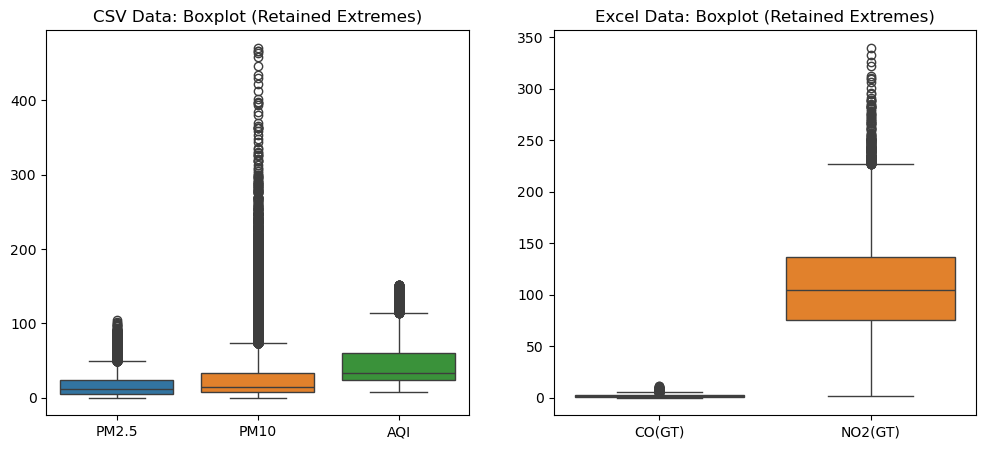

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_global_capped[['PM2.5', 'PM10', 'AQI']], ax=axes[0])
axes[0].set_title('CSV Data: Boxplot (Retained Extremes)')

sns.boxplot(data=df_uci_capped[['CO(GT)', 'NO2(GT)']], ax=axes[1])
axes[1].set_title('Excel Data: Boxplot (Retained Extremes)')
plt.show()

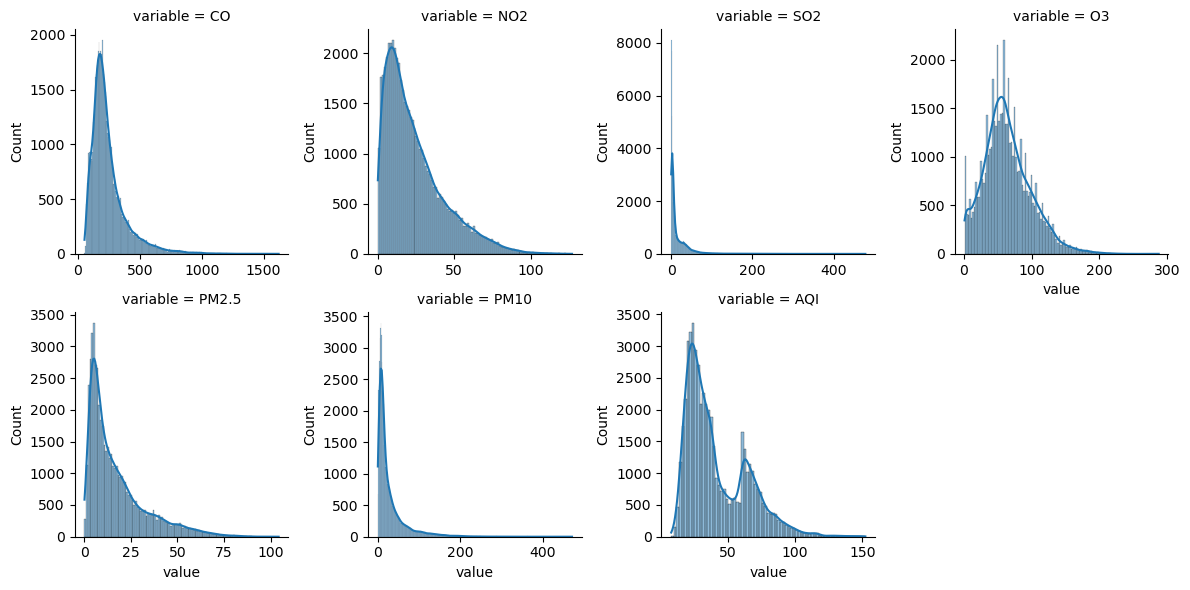

<Axes: ylabel='CO'>

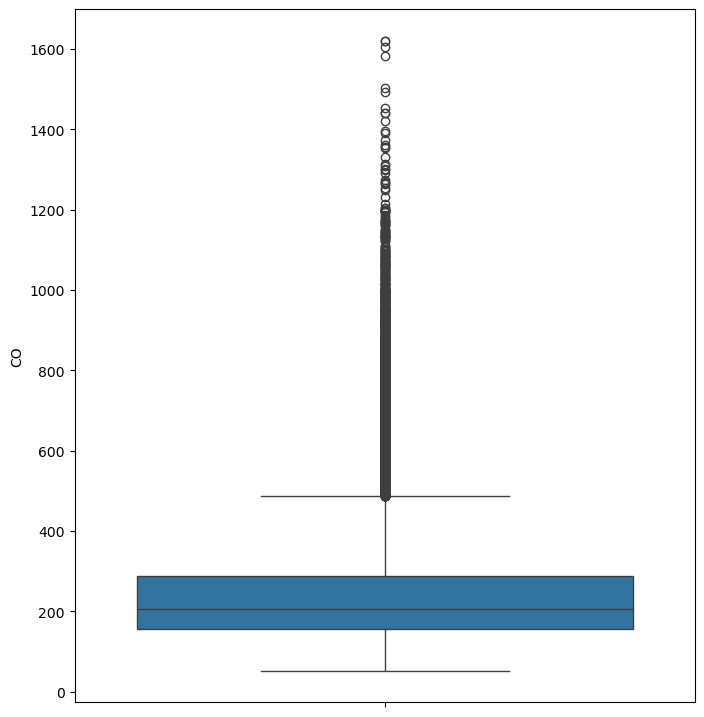

In [34]:
df_numeric = df_global_capped.melt(value_vars=['CO','NO2','SO2','O3','PM2.5','PM10','AQI'])

g = sns.FacetGrid(df_numeric, col="variable", col_wrap=4, sharex=False, sharey=False)
g.map(sns.histplot, "value", kde=True)
plt.show()
plt.figure(figsize=(8,9))
plt.xticks(rotation='vertical')
sns.boxplot(data=df_global_capped['CO'])
#full lệch phải

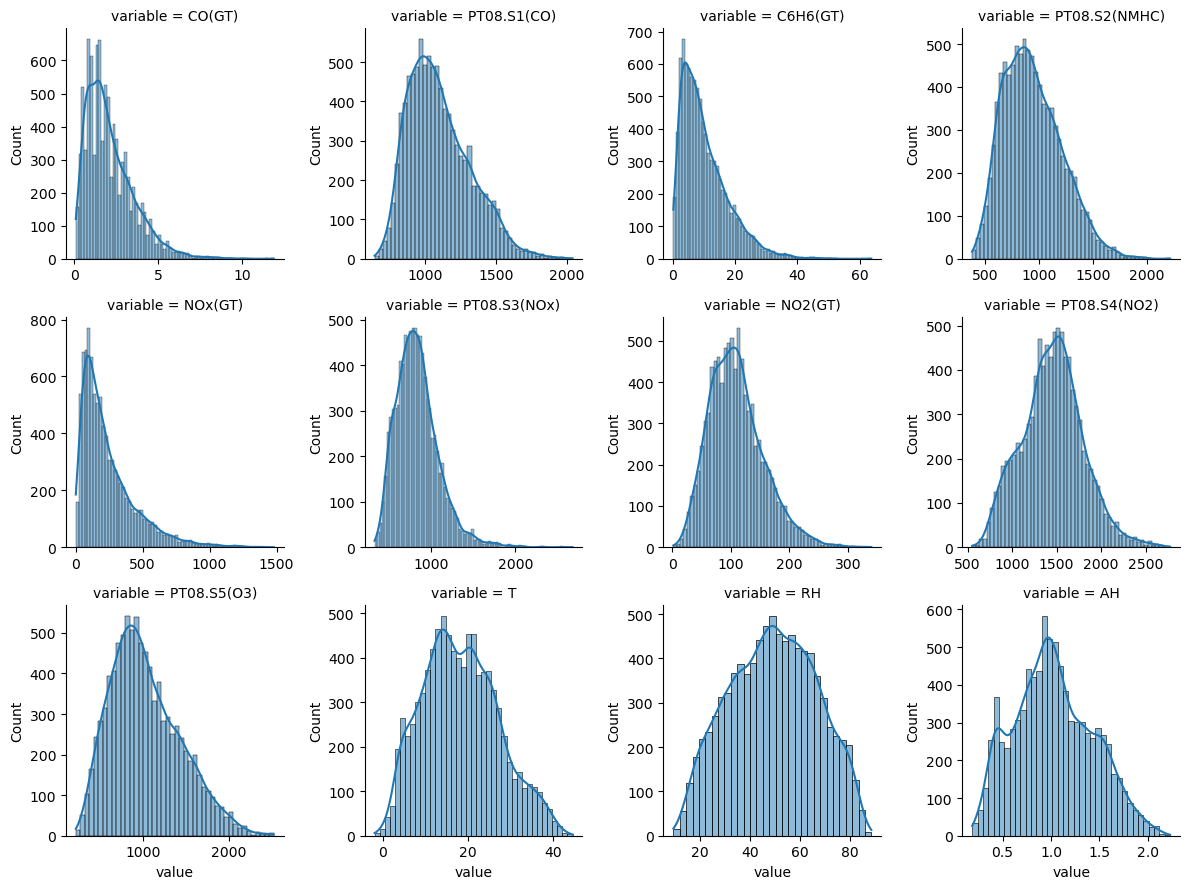

In [35]:
df_melt = df_uci_capped.melt(value_vars=['CO(GT)', 'PT08.S1(CO)',  'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'])

g = sns.FacetGrid(df_melt, col="variable", col_wrap=4, sharex=False, sharey=False)
g.map(sns.histplot, "value", kde=True)

plt.show()

## Tính AQI cho UCI ( hiện chỉ có CO va NO2 nên AQI chỉ mang tính chất tham khảo )

In [36]:
AQI_breakpint = {
    'CO':[
        (0.0, 4.4, 0, 50),
        (4.5, 9.4, 51, 100),
        (9.5, 12.4, 101, 150),
        (12.5, 15.4, 151, 200),
        (15.5, 30.4, 201, 300),
        (30.5, 40.4, 301, 400),
        (40.5, 50.4, 401, 500)
    ],
    'NO2':[
        (0.0, 0.053, 0,50),
        (0.054,0.1,51,100),
        (0.101,0.36,101,150),
        (0.361,0.649,151,200),
        (0.65, 1.24, 201, 300),
        (1.25, 1.64, 301, 400),
        (1.65, 2.04, 401, 500)
    ]
}

#quy đổi từ mg/m3 sang ppm và μg/m3 sang ppb

df_uci_capped["NO2(GT)"] = df_uci_capped["NO2(GT)"] * 24.45 / 46 / 1000 # tính theo ppm
df_uci_capped["CO(GT)"] = df_uci_capped["CO(GT)"] * 24.45 / 28   
def cal_AQI_per(c, break_point):
    if pd.isna(c) or c < 0:
        return np.nan
        
    # Xử lý trường hợp vượt mốc Hazardous cực đại (chạm trần max AQI = 500)
    if c > break_point[-1][1]:
        return break_point[-1][3]
        
    for i in range(len(break_point)):
        bp_lo, bp_hi, i_lo, i_hi = break_point[i]
        
        # Tìm ngưỡng dưới tiếp theo, nếu là khoảng hở (Gap) thì lấp đầy nó
        next_bp_lo = break_point[i+1][0] if i + 1 < len(break_point) else float('inf')
        
        # Nếu c nhỏ hơn mốc dưới của khoảng tiếp theo, thì nó thuộc khoảng hiện tại
        if c < next_bp_lo:
            # Ép c vào giới hạn để không gây chênh lệch khi nội suy
            c_calc = min(c, bp_hi)
            c_calc = max(c_calc, bp_lo)
            return ((i_hi - i_lo) / (bp_hi - bp_lo)) * (c_calc - bp_lo) + i_lo
            
    return np.nan
df_uci_capped["AQI_CO"] = df_uci_capped["CO(GT)"].apply(
    lambda x: cal_AQI_per(x, AQI_breakpint['CO'])
)
df_uci_capped["AQI_NO2"] = df_uci_capped["NO2(GT)"].apply(
    lambda x: cal_AQI_per(x, AQI_breakpint['NO2'])
)
# Thử lại max(axis=1), lần này không còn NaN nữa
df_uci_capped['AQI'] = df_uci_capped[['AQI_CO', 'AQI_NO2']].max(axis=1)

In [37]:
df_uci_capped['AQI'].sort_values(ascending=False).head()
df_uci_capped['AQI'].isna().sum()

np.int64(0)

In [38]:
df_uci_capped.describe()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,AQI_CO,AQI_NO2,AQI
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,8991.000000,8991.000000,8991.000000,9357.000000,9357.000000,9357.000000
mean,1.860473,1102.932861,10.178839,942.019653,241.908463,832.634949,0.058265,1453.172974,1032.422485,18.316055,49.232361,1.025530,21.083868,55.626755,55.662569
std,1.250214,218.201828,7.503296,267.864655,204.308090,255.708939,0.024690,343.201355,404.442047,8.832889,17.316393,0.403813,14.008071,23.254819,23.235675
min,0.087321,647.250000,0.149048,383.250000,2.000000,322.000000,0.001063,551.000000,221.000000,-1.900000,9.175000,0.184679,0.992289,1.002871,2.507178
25%,0.960536,937.500000,4.477145,736.000000,96.000000,654.000000,0.040396,1227.000000,733.250000,11.787500,35.812500,0.736769,10.915180,38.109105,38.109105
50%,1.571786,1066.750000,8.289085,910.333313,180.000000,803.500000,0.055718,1459.500000,970.000000,17.750000,49.549999,0.995395,17.861201,52.830191,52.909552
75%,2.532322,1238.750000,14.096486,1119.000000,326.000000,967.500000,0.072500,1668.250000,1293.000000,24.400000,62.500000,1.313701,28.776383,70.706059,70.762678
max,10.391250,2039.750000,63.741478,2214.000000,1479.000000,2682.750000,0.180558,2775.000000,2522.750000,44.600002,88.724998,2.231036,116.059046,116.051504,116.059046


In [39]:
# Tạo category (dùng cho alert sau này)
aqi_categories = ['Good', 'Moderate', 'Unhealthy for Sensitive', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
bins = [0, 50, 100, 150, 200, 300, 500]
df_uci_capped['AQI_category'] = pd.cut(df_uci_capped['AQI'], bins=bins, labels=aqi_categories, right=False)

## Lag Features

In [40]:
pollutants = ["CO(GT)", "NOx(GT)", "C6H6(GT)", 'T', 'RH']  # chọn các cột quan trọng

for col in pollutants:
    for lag in [1, 3, 6, 12, 24]:           # lag phổ biến
        df_uci_capped[f'{col}_lag_{lag}h'] = df_uci_capped[col].shift(lag)

# Sửa lỗi: Thêm lag cho df_global_capped
pollutants_global = ['CO', 'NO2', 'SO2', 'O3', 'PM2.5', 'PM10']
for col in pollutants_global:
    for lag in [1, 3, 6, 12, 24]:
        df_global_capped[f'{col}_lag_{lag}h'] = df_global_capped[col].shift(lag)

vietnam_cols = ['CO', 'Dew', 'Humidity', 'NO2', 'O3', 'PM10',
       'PM2.5', 'SO2', 'Temperature', 'Wind']
for col in vietnam_cols:
    for lag in [1, 3, 6, 12, 24]:
        df_vietnam_capped[f'{col}_lag_{lag}h'] = df_vietnam_capped[col].shift(lag)

## Rolling mean

In [41]:
df_vietnam_col = df_vietnam.select_dtypes(include=['number']).columns
df_vietnam_col

Index(['Station ID', 'AQI index', 'CO', 'Dew', 'Humidity', 'NO2', 'O3', 'PM10',
       'PM2.5', 'SO2', 'Temperature', 'Wind'],
      dtype='object')

In [42]:
for col in pollutants:
    for window in [3, 6, 12, 24]:
        df_uci_capped[f'{col}_rolling_mean_{window}h'] = df_uci_capped[col].rolling(window=window, min_periods=1).mean()
        df_uci_capped[f'{col}_rolling_std_{window}h']  = df_uci_capped[col].rolling(window=window, min_periods=1).std()

# Điền 0 cho các giá trị NaN phát sinh từ rolling_std với min_periods=1
# df_uci_capped.fillna(0, inplace=True)


for col in pollutants_global:
    for window in [3, 6, 12, 24]:
        df_global_capped[f'{col}_rolling_mean_{window}h'] = df_global_capped[col].rolling(window=window, min_periods=1).mean()
        df_global_capped[f'{col}_rolling_std_{window}h']  = df_global_capped[col].rolling(window=window, min_periods=1).std()

df_global_capped.fillna(0, inplace=True)

for col in vietnam_cols:
    for window in [3, 6, 12, 24]:
        df_vietnam_capped[f'{col}_rolling_mean_{window}h'] = df_vietnam_capped[col].rolling(window=window, min_periods=1).mean()
        df_vietnam_capped[f'{col}_rolling_std_{window}h']  = df_vietnam_capped[col].rolling(window=window, min_periods=1).std()


C:\Users\fpt\AppData\Local\Temp\ipykernel_11588\4043685347.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_vietnam_capped[f'{col}_rolling_std_{window}h']  = df_vietnam_capped[col].rolling(window=window, min_periods=1).std()
C:\Users\fpt\AppData\Local\Temp\ipykernel_11588\4043685347.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_vietnam_capped[f'{col}_rolling_mean_{window}h'] = df_vietnam_capped[col].rolling(window=window, min_periods=1).mean()
C:\Users\fpt\AppData\Local\Temp\ipykernel_11588\4043685347.py:20: Per

In [43]:
df_uci_capped['AQI'].isna().sum()

np.int64(0)

## Extract datetime features

In [44]:
# Season (VN-style)
def get_season(m):
    if m in [12, 1, 2]: return 'Winter'
    elif m in [3, 4, 5]: return 'Spring'
    elif m in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

df_uci_capped['hour']        = df_uci_capped.index.hour
df_uci_capped['dayofweek']   = df_uci_capped.index.dayofweek
df_uci_capped['month']       = df_uci_capped.index.month
df_uci_capped['is_weekend']  = df_uci_capped.index.dayofweek.isin([5, 6]).astype(int)

df_uci_capped['season'] = df_uci_capped.index.month.map(get_season)

# cyclical encoding (Sin/Cos) cho biến thời gian để giúp model nắm bắt khoảng cách thời gian chuẩn hơn

df_uci_capped['hour_sin'] = np.sin(2 * np.pi * df_uci_capped['hour'] / 24.0)
df_uci_capped['hour_cos'] = np.cos(2 * np.pi * df_uci_capped['hour'] / 24.0)
df_uci_capped['month_sin'] = np.sin(2 * np.pi * df_uci_capped['month'] / 12.0)
df_uci_capped['month_cos'] = np.cos(2 * np.pi * df_uci_capped['month'] / 12.0)


df_hanoi['hour']        = df_hanoi.index.hour
df_hanoi['dayofweek']   = df_hanoi.index.dayofweek
df_hanoi['month']       = df_hanoi.index.month
df_hanoi['is_weekend']  = df_hanoi.index.dayofweek.isin([5, 6]).astype(int)

df_hanoi['season'] = df_hanoi.index.month.map(get_season)

# cyclical encoding (Sin/Cos) cho biến thời gian để giúp model nắm bắt khoảng cách thời gian chuẩn hơn

df_hanoi['hour_sin'] = np.sin(2 * np.pi * df_hanoi['hour'] / 24.0)
df_hanoi['hour_cos'] = np.cos(2 * np.pi * df_hanoi['hour'] / 24.0)
df_hanoi['month_sin'] = np.sin(2 * np.pi * df_hanoi['month'] / 12.0)
df_hanoi['month_cos'] = np.cos(2 * np.pi * df_hanoi['month'] / 12.0)



df_global_capped['Date'] = pd.to_datetime(df_global_capped['Date'])
df_global_capped['hour']        = df_global_capped['Date'].dt.hour
df_global_capped['dayofweek']   = df_global_capped['Date'].dt.dayofweek
df_global_capped['month']       = df_global_capped['Date'].dt.month
df_global_capped['is_weekend']  = df_global_capped['Date'].dt.dayofweek.isin([5, 6]).astype(int)

df_global_capped['season']      = df_global_capped['Date'].dt.month.map(get_season)

df_global_capped['hour_sin']    = np.sin(2 * np.pi * df_global_capped['hour'] / 24.0)
df_global_capped['hour_cos']    = np.cos(2 * np.pi * df_global_capped['hour'] / 24.0)
df_global_capped['month_sin']   = np.sin(2 * np.pi * df_global_capped['month'] / 12.0)
df_global_capped['month_cos']   = np.cos(2 * np.pi * df_global_capped['month'] / 12.0)


df_vietnam_capped['hour']        = df_vietnam_capped.index.hour
df_vietnam_capped['dayofweek']   = df_vietnam_capped.index.dayofweek
df_vietnam_capped['month']       = df_vietnam_capped.index.month
df_vietnam_capped['is_weekend']  = df_vietnam_capped.index.dayofweek.isin([5, 6]).astype(int)

df_vietnam_capped['season']      = df_vietnam_capped.index.month.map(get_season)

df_vietnam_capped['hour_sin']    = np.sin(2 * np.pi * df_vietnam_capped['hour'] / 24.0)
df_vietnam_capped['hour_cos']    = np.cos(2 * np.pi * df_vietnam_capped['hour'] / 24.0)
df_vietnam_capped['month_sin']   = np.sin(2 * np.pi * df_vietnam_capped['month'] / 12.0)
df_vietnam_capped['month_cos']   = np.cos(2 * np.pi * df_vietnam_capped['month'] / 12.0)


C:\Users\fpt\AppData\Local\Temp\ipykernel_11588\2156622965.py:53: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_vietnam_capped['hour']        = df_vietnam_capped.index.hour
C:\Users\fpt\AppData\Local\Temp\ipykernel_11588\2156622965.py:54: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_vietnam_capped['dayofweek']   = df_vietnam_capped.index.dayofweek
C:\Users\fpt\AppData\Local\Temp\ipykernel_11588\2156622965.py:55: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many 

## Normalize / Scale



In [45]:
scale_cols = [col for col in df_uci_capped.columns if df_uci_capped[col].dtype in ['float64', 'int64'] 
              and not col.startswith('AQI') and col not in ['is_weekend', 'hour', 'month', 'dayofweek']] # giữ lag/rolling để chuẩn hóa và loại bỏ các biến categorical]

df_uci_capped[scale_cols] = scaler.fit_transform(df_uci_capped[scale_cols])

# Lưu scaler để dùng sau (inference)
import joblib
joblib.dump(scaler, '../models/scaler_uci.pkl')


scale_cols_global = [col for col in df_global_capped.columns if df_global_capped[col].dtype in ['float64', 'int64'] and not col.startswith('AQI') and col not in ['is_weekend', 'hour', 'month', 'dayofweek']]
scaler_global = StandardScaler()
df_global_capped[scale_cols_global] = scaler_global.fit_transform(df_global_capped[scale_cols_global])

import joblib
joblib.dump(scaler_global, '../models/scaler_global.pkl')


['../models/scaler_global.pkl']

**Logarit để cần bằng skewed**

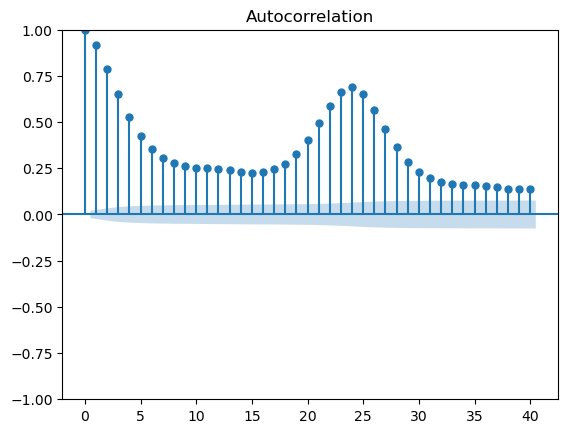

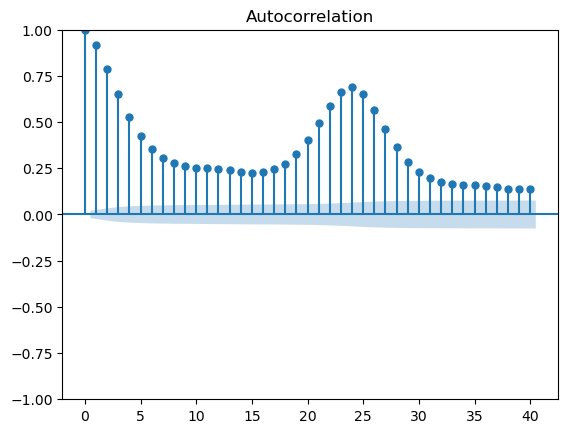

In [46]:
plot_acf(df_uci_capped['AQI'])

In [47]:
df_hanoi.columns

Index(['pm25', 'pm10', 'o3', 'no2', 'so2', 'co', 'pm25_raw', 'pm25_imputed',
       'pm10_raw', 'pm10_imputed', 'o3_raw', 'o3_imputed', 'no2_raw',
       'no2_imputed', 'so2_raw', 'so2_imputed', 'co_raw', 'co_imputed', 'hour',
       'dayofweek', 'month', 'is_weekend', 'season', 'hour_sin', 'hour_cos',
       'month_sin', 'month_cos'],
      dtype='object')

In [48]:
# # dùng logarit value để nornal háo skew cho dữ liệu
# for col in ['CO','NO2','SO2','O3','PM2.5','PM10','AQI']:
#     df_global_capped[col] = np.log1p(df_global_capped[col])
#     # print((df_global_capped[col] <= -1).sum())

# for col in ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)',
#        'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
#        'PT08.S5(O3)']:
#     df_uci_capped[col] = np.log1p(df_uci_capped[col])
#     # print((df_uci_capped[col] <= -1).sum())

## Data Validation Pipeline (Great Expectations)

Áp dụng Great Expectations để tự động hóa việc kiểm tra tính đúng đắn của dữ liệu đã qua xử lý. Phục vụ cho bước tiếp theo trong pipeline.

In [49]:
def validate_dataframe(df, suite_name, batch_definition):

    batch = batch_definition.get_batch(
        batch_parameters={"dataframe": df}
    )

    validator = context.get_validator(
        batch=batch,
        expectation_suite=suite_name
    )

    results = validator.validate()

    return results.success

In [50]:
suite_uci = context.suites.add(
    gx.ExpectationSuite(name="uci_air_quality_suite")
)
batch_definition_uci = data_asset.add_batch_definition_whole_dataframe(
    "uci_batch"
)

In [51]:


results_uci = []

expected_columns_uci = ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 
                        'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
for col in expected_columns_uci:
    suite_uci.add_expectation(gx.expectations.ExpectColumnToExist(column=col))
    suite_uci.add_expectation(gx.expectations.ExpectColumnValuesToNotBeNull(column=col, mostly=0.85))

# Nhiệt độ T [-50, 60], Độ ẩm RH [0, 100]
suite_uci.add_expectation(
    gx.expectations.ExpectColumnValuesToBeBetween(
        column="T",
        min_value=-50,
        max_value=60
    )
)

suite_uci.add_expectation(
    gx.expectations.ExpectColumnValuesToBeBetween(
        column="RH",
        min_value=0,
        max_value=100
    )
)


# Dữ liệu cảm biến phải >= 0
sensor_columns = ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)']
for col in sensor_columns:
    suite_uci.add_expectation(
        gx.expectations.ExpectColumnValuesToBeBetween(
            column=col,
            min_value=0,
            mostly=0.99
        )
    )
    

# Validate
if not validate_dataframe(df_uci_capped, suite_uci, batch_definition_uci):
    print('Fail data')

Calculating Metrics:   0%|          | 0/60 [00:00<?, ?it/s]

In [52]:
data_asset_global = datasource.add_dataframe_asset(name="global_asset")
suite_global = context.suites.add(
    gx.ExpectationSuite(name="global_air_quality_suite")
)

batch_definition_global = data_asset_global.add_batch_definition_whole_dataframe(
    "global_batch"
)

In [53]:
# 3. Cấu hình Expectations cho df_global_capped

results_global = []

expected_columns_global = [
     'City', 'Date', 'CO', 'NO2', 'SO2',
    'O3', 'PM2.5', 'PM10', 'AQI'
]

for col in expected_columns_global:
    
    suite_global.add_expectation(
        gx.expectations.ExpectColumnToExist(column=col)
    )
    
pollutant_columns = ['CO', 'NO2', 'SO2', 'O3', 'PM2.5', 'PM10', 'AQI']

for col in pollutant_columns:
    
    suite_global.add_expectation(
        gx.expectations.ExpectColumnValuesToBeBetween(
            column=col,
            min_value=0.0,
            mostly=0.95
        )
    )
    




suite_global.add_expectation(
    gx.expectations.ExpectColumnValuesToNotBeNull(
        column="City",
        mostly=0.99
    )
)

if not validate_dataframe(df_global_capped, suite_global, batch_definition_uci):
    print('Fail data')

Calculating Metrics:   0%|          | 0/41 [00:00<?, ?it/s]

In [54]:
data_asset_hanoi = datasource.add_dataframe_asset(name="hanoi_asset")
suite_hanoi = context.suites.add(
    gx.ExpectationSuite(name="hanoi_air_quality_suite")
)

batch_definition_hanoi = data_asset_hanoi.add_batch_definition_whole_dataframe(
    "hanoi_batch"
)

In [55]:
# 3. Cấu hình Expectations cho df_hanoi_capped

results_hanoi = []

expected_columns_hanoi = ['pm25', 'pm10', 'o3', 'no2', 'so2', 'co']
for col in expected_columns_hanoi:
    
    suite_hanoi.add_expectation(
        gx.expectations.ExpectColumnToExist(column=col)
    )
    
pollutant_columns = ['pm25', 'pm10', 'o3', 'no2', 'so2', 'co']

for col in pollutant_columns:
    
    suite_hanoi.add_expectation(
        gx.expectations.ExpectColumnValuesToBeBetween(
            column=col,
            min_value=0.0,
            mostly=0.95
        )
    )

    suite_hanoi.add_expectation(
        gx.expectations.ExpectColumnValuesToNotBeNull(
            column=col,
            mostly=0.99
        )
    )

if not validate_dataframe(df_hanoi, suite_hanoi, batch_definition_uci):
    print('Fail data')

Calculating Metrics:   0%|          | 0/39 [00:00<?, ?it/s]

In [56]:
df_hanoi.isna().sum().sort_values(ascending=False)

o3_raw          670
co_raw          649
no2_raw         582
so2_raw         575
pm25_raw        276
pm10_raw        275
pm25              0
month_sin         0
hour_cos          0
hour_sin          0
season            0
is_weekend        0
month             0
dayofweek         0
hour              0
co_imputed        0
no2_imputed       0
so2_imputed       0
pm10              0
o3_imputed        0
pm10_imputed      0
pm25_imputed      0
co                0
so2               0
no2               0
o3                0
month_cos         0
dtype: int64

In [57]:
# 4. Trích xuất và in danh sách các cảnh báo (Failed Expectations)
context.build_data_docs()
context.open_data_docs()

In [58]:
df_uci_capped.to_parquet('../data/processed/uci_cleaned.parquet')
df_global_capped.to_parquet('../data/processed/global_cleaned.parquet')
df_hanoi.to_parquet('../data/processed/hanoi_cleaned.parquet')
df_vietnam_capped.to_parquet('../data/processed/vietnam_cleaned.parquet')

In [59]:
df_hanoi.head(100)

,pm25,pm10,o3,no2,so2,co,pm25_raw,pm25_imputed,pm10_raw,pm10_imputed,...,co_imputed,hour,dayofweek,month,is_weekend,season,hour_sin,hour_cos,month_sin,month_cos
date,,,,,,,,,,,,,,,,,,,,,
2014-01-01,205.668933,124.0,22.0,40.0,6.0,28.0,NaN,True,124.0,False,...,False,0,2,1,0,Winter,0.0,1.0,0.500000,0.866025
2014-01-02,186.000000,144.0,69.0,39.0,8.0,43.0,186.0,False,144.0,False,...,False,0,3,1,0,Winter,0.0,1.0,0.500000,0.866025
2014-01-03,227.000000,151.0,24.0,25.0,12.0,28.0,227.0,False,151.0,False,...,False,0,4,1,0,Winter,0.0,1.0,0.500000,0.866025
2014-01-04,253.000000,133.0,44.5,30.0,8.5,30.5,253.0,False,NaN,True,...,True,0,5,1,1,Winter,0.0,1.0,0.500000,0.866025
2014-01-05,220.500000,115.0,65.0,35.0,5.0,33.0,NaN,True,115.0,False,...,False,0,6,1,1,Winter,0.0,1.0,0.500000,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-04-06,107.000000,31.0,13.0,36.0,8.0,24.0,107.0,False,31.0,False,...,False,0,6,4,1,Spring,0.0,1.0,0.866025,-0.500000
2014-04-07,75.000000,47.0,11.0,30.0,13.0,27.0,75.0,False,47.0,False,...,False,0,0,4,0,Spring,0.0,1.0,0.866025,-0.500000
2014-04-08,113.000000,43.0,9.0,25.0,14.0,20.0,113.0,False,43.0,False,...,False,0,1,4,0,Spring,0.0,1.0,0.866025,-0.500000
